In [1]:
import pandas as pd 
import matplotlib.pyplot as plt
import numpy as np
import seaborn as snc
from scipy import stats

In [2]:
import warnings
warnings.filterwarnings('ignore')

Нужно будет выявить основные признаки, по которым происходит корреляция критерия цена-спрос. Для этого перед непосредственно анализом для выводов посмотрим на признаки в общем виде, *изучим общую ценовую тенденцию, дальше разобьем данные по временным сегментам, ценовым сегментам, пользовательским данным.*

In [3]:
df = pd.read_csv('./datasets/T_games_dataset.csv', parse_dates=['order_day'])
df['revenue'] = df['good_price'] * df['good_cnt']
df['log_price'] = np.log1p(df['good_price'])
df['log_sales'] = np.log1p(df['good_cnt'])
df['log_cnt'] = np.log1p(df['good_cnt'])
df['year_month'] = df['order_day'].dt.to_period('M')
df['is_discounted'] = df['category_name'].str.contains('скидк|акци|распродаж', case=False, regex=True)

In [4]:
df.describe()

,id,order_day,category_id,good_id,good_price,good_cnt,age,monthly_income_amt,steam_popularity_score,revenue,log_price,log_sales,log_cnt
count,8.869900e+04,88699,88699.000000,8.869900e+04,88699.000000,88699.0,88699.000000,8.869900e+04,88699.000000,88699.000000,88699.000000,88699.000000,88699.000000
mean,1.500462e+09,2023-01-17 22:33:16.459937280,28968.248932,1.135675e+06,584.402189,1.0,26.600187,9.026706e+04,475.555395,584.402189,5.550455,0.693147,0.693147
min,1.500208e+09,2022-02-07 00:00:00,28555.000000,8.472910e+05,2.320000,1.0,1.000000,-5.246740e+05,0.000000,2.320000,1.199965,0.693147,0.693147
25%,1.500337e+09,2022-09-14 00:00:00,28562.000000,8.488950e+05,119.200000,1.0,20.000000,2.600000e+04,0.000000,119.200000,4.789157,0.693147,0.693147
50%,1.500457e+09,2023-01-21 00:00:00,28574.000000,1.123866e+06,329.000000,1.0,26.000000,6.800000e+04,0.000000,329.000000,5.799093,0.693147,0.693147
75%,1.500578e+09,2023-05-28 00:00:00,28577.000000,1.395053e+06,679.000000,1.0,32.000000,1.381100e+05,282.000000,679.000000,6.522093,0.693147,0.693147
max,1.500750e+09,2023-10-29 00:00:00,35255.000000,1.774802e+06,10656.300000,1.0,86.000000,7.190000e+06,4981.000000,10656.300000,9.274000,0.693147,0.693147
std,1.448781e+05,NaN,1061.080699,2.831782e+05,877.856786,0.0,8.312742,1.422906e+05,1008.816453,877.856786,1.434418,0.000000,0.000000


В основном при работе с общими данным по стоимости игры будем использовать прологарифмированные значения, чтобы сгладить разницу между основной массой значений и аномальными значениями.

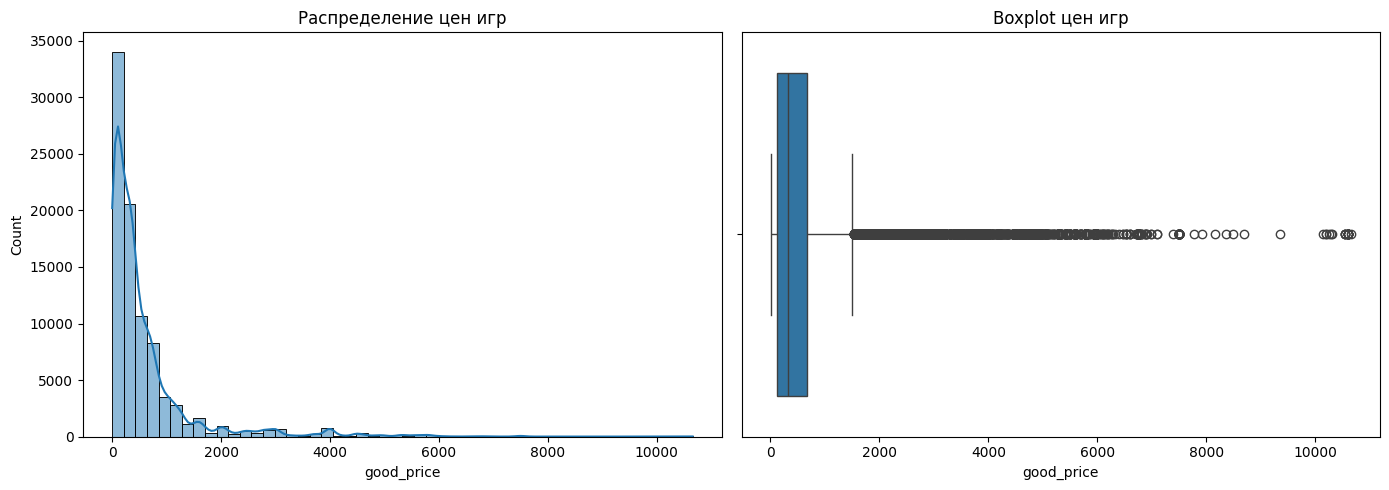

In [5]:
plt.figure(figsize=(14, 5))
plt.subplot(1, 2, 1)
snc.histplot(df['good_price'], bins=50, kde=True)
plt.title('Распределение цен игр')

plt.subplot(1, 2, 2)
snc.boxplot(x=df['good_price'])
plt.title('Boxplot цен игр')
plt.tight_layout()
plt.show()

df['price_segment'] = pd.cut(df['good_price'], 
                        bins=[0, 500, 1500, 3000, np.inf],
                        labels=['<500', '500-1500', '1500-3000', '>3000'])

Сразу видим из графиков большой разброс в цене, хотя основная часть продаж сконцентрирована в бюджетной части, 75% продаж оказались меньше 800р.

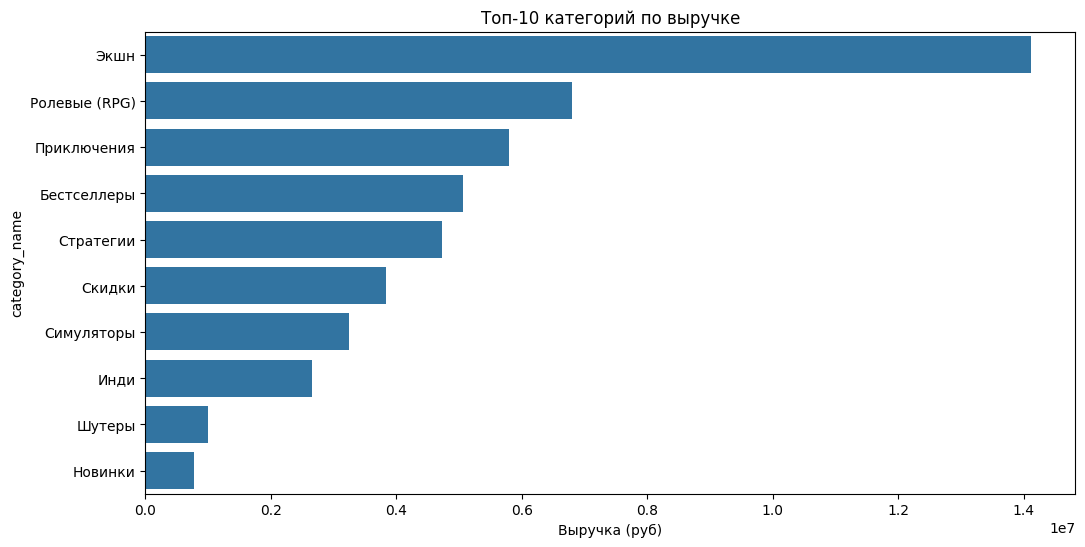

In [6]:
top_categories = df.groupby('category_name').agg(
    avg_price=('good_price', 'mean'),
    total_sales=('good_cnt', 'sum'),
    total_revenue=('revenue', 'sum')
).sort_values('total_revenue', ascending=False).head(10)

plt.figure(figsize=(12, 6))
snc.barplot(data=top_categories, x='total_revenue', y=top_categories.index)
plt.title('Топ-10 категорий по выручке')
plt.xlabel('Выручка (руб)')
plt.show()

Мы уже рассмотрели различные категории по популярности, пришло время оценить выручку и определить, как цена игры связана с категориями и как это влияет на количество продаж. Для общего представления посмотрим на топ категорий по выручке. Не удивительно, что видим много переплетений с популярностью игры.

income_group
<50k        542.024693
50-100k     584.577148
100-150k    615.507879
>150k       638.443162
Name: good_price, dtype: float64

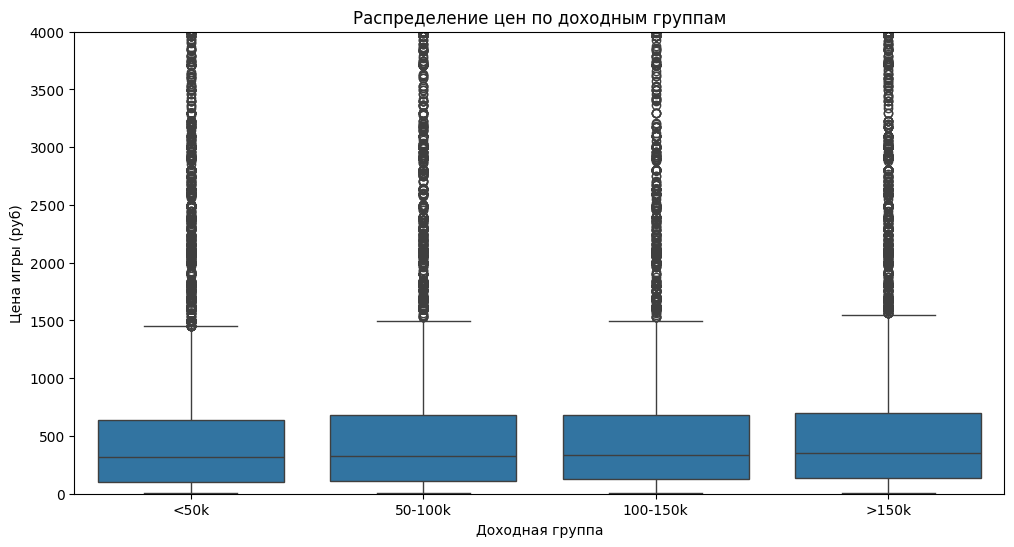

In [7]:
df['income_group'] = pd.cut(df['monthly_income_amt'], 
                        bins=[0, 50000, 100000, 150000, np.inf],
                        labels=['<50k', '50-100k', '100-150k', '>150k'])

display(df.groupby(by=['income_group'])['good_price'].mean())
plt.figure(figsize=(12, 6))
snc.boxplot(data=df, x='income_group', y='good_price')
plt.title('Распределение цен по доходным группам')
plt.xlabel('Доходная группа')
plt.ylabel('Цена игры (руб)')
plt.ylim((0, 4000))
plt.show()

Сразу хочется проверить, действительно ли в среднем люди с более высоким доходом покупают более дорогие игры. Это подтверждается, хотя и нет сильных отклонений.

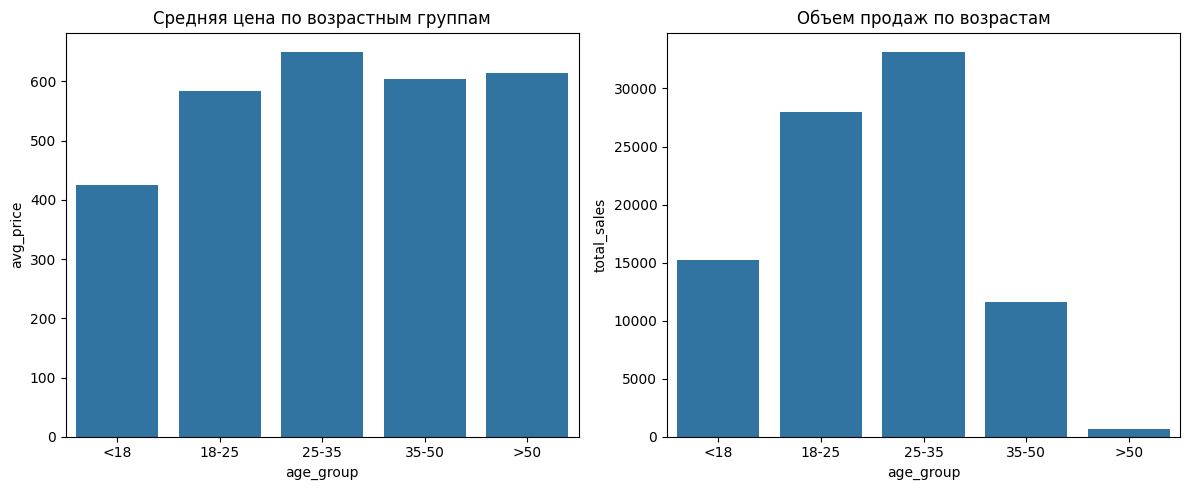

In [8]:
df['age_group'] = pd.cut(df['age'], 
                        bins=[0, 18, 25, 35, 50, np.inf],
                        labels=['<18', '18-25', '25-35', '35-50', '>50'])

age_price = df.groupby('age_group').agg(
    avg_price=('good_price', 'mean'),
    total_sales=('good_cnt', 'sum')
).reset_index()

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
snc.barplot(data=age_price, x='age_group', y='avg_price')
plt.title('Средняя цена по возрастным группам')

plt.subplot(1, 2, 2)
snc.barplot(data=age_price, x='age_group', y='total_sales')
plt.title('Объем продаж по возрастам')
plt.tight_layout()
plt.show()

Сразу видно, что большинство покупателей младше 18 лет покупают дешевые игры. начиная с 20-25 лет ценовая ситуация примерно уравнивается. В это время общее количество покупок сконцентрировано у среднего возраста покупателя.

После предварительного анализа переходим к непосредственно анализу эластичности цены-спроса по разным признакам. Поскольку мы видели большие отклонения в спросе и в выручке у различных жанров игр, стоит посмотреть, на продажу каких жанров больше всего влияет изменение цены. Как и говорилось ранее, рассматривать будем логарифм значений.

In [9]:
game_stats = df.groupby('good_id').agg({
    'good_price': 'mean',
    'good_cnt': 'sum',
    'category_name': 'first'
})

game_stats['log_price'] = np.log(game_stats['good_price'])
game_stats['log_sales'] = np.log(game_stats['good_cnt'])

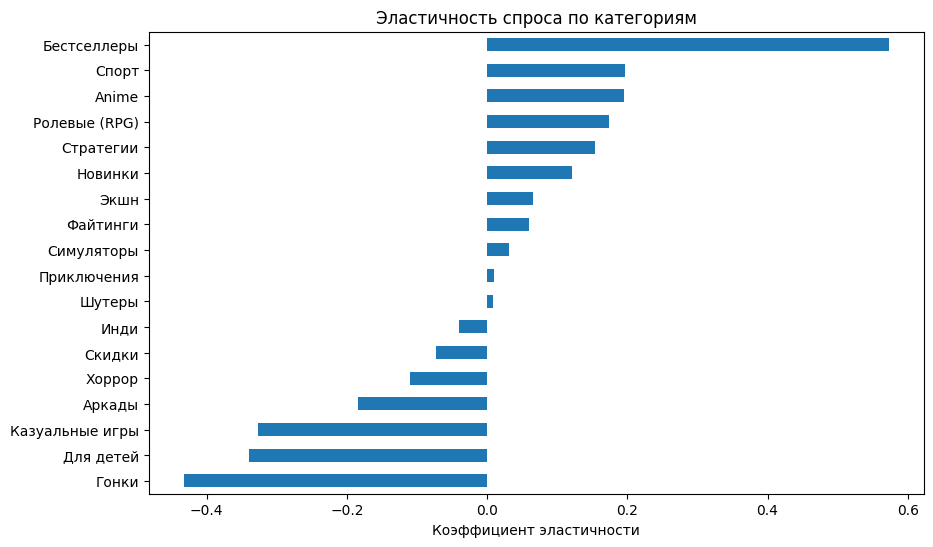

In [14]:
from sklearn.linear_model import LinearRegression

elasticity_by_category = {}
for category in df['category_name'].unique():
    subset = game_stats[game_stats['category_name'] == category]
    if len(subset) > 10:
        X = subset[['log_price']]
        y = subset['log_sales']
        model = LinearRegression().fit(X, y)
        elasticity_by_category[category] = model.coef_[0]

pd.Series(elasticity_by_category).sort_values().plot(kind='barh', figsize=(10, 6))
plt.title('Эластичность спроса по категориям')
plt.xlabel('Коэффициент эластичности')
plt.show()

Рассматриваем то, насколько меняется количество продаж игр в зависимости от цены. То есть смотрим на то, насколько часто покупают более дорогие игры в конкретном жанре. Зависимость рассматриваем всего по одному параметру: цена игры, поэтому в качестве характеристики будем использовать оптимальный коэффициент при рассмотрении корреляции между ценой и спросом.

In [15]:
sorted_categories = pd.Series(elasticity_by_category).sort_values().index
elasticity_table = pd.DataFrame.from_dict(elasticity_by_category, orient='index', 
                                    columns=['Эластичность']).sort_values('Эластичность')
elasticity_table['+10% цены -> % изменения продаж'] = elasticity_table['Эластичность'] * 10
elasticity_table['-10% цены -> % изменения продаж'] = elasticity_table['Эластичность'] * -10

def color_elasticity(val):
    color = 'red' if val < -0.15 else ('green' if val > 0.15 else 'orange')
    return f'color: {color}'

display(elasticity_table.style.applymap(color_elasticity, subset=['Эластичность'])
    .format({
        'Эластичность': '{:.2f}',
        '+10% цены -> % изменения продаж': '{:.1f}%',
        '-10% цены -> % изменения продаж': '{:.1f}%',
        ('good_price', 'mean'): '{:.0f}',
        ('good_price', 'median'): '{:.0f}',
        ('good_cnt', 'sum'): '{:,}',
        ('revenue', 'sum'): '{:,}'
    }))

,Эластичность,+10% цены -> % изменения продаж,-10% цены -> % изменения продаж
Гонки,-0.43,-4.3%,4.3%
Для детей,-0.34,-3.4%,3.4%
Казуальные игры,-0.33,-3.3%,3.3%
Аркады,-0.18,-1.8%,1.8%
Хоррор,-0.11,-1.1%,1.1%
Скидки,-0.07,-0.7%,0.7%
Инди,-0.04,-0.4%,0.4%
Шутеры,0.01,0.1%,-0.1%
Приключения,0.01,0.1%,-0.1%
Симуляторы,0.03,0.3%,-0.3%


Следующие особенности: выделяются Бестселлеры. т е их и остальные жанры, у которых на высоких ценах количество продаж больше, скорее всего не получится построить построить хорошей скидочной модели. Потому что понижение цены явным образом не влияет на повышение спроса. С другой стороны, можно протестировать следующий способ: делать скидки только на самые дорогие игры в этих категориях. *Тогда есть вероятность того, что дорогие игры из данной категории, став дешевле, все таки вызовут к себе спрос.* Однозначно, аналогичное действие с отрицательным коэффициентом приведет к повышению спроса. Хуже дела обстоят с играми из "оранжевой" категории, где цена на спрос практически не влияет на цену. В данном случае эти жанры нам менее интересны.

In [16]:
df[df['category_name'] == 'Скидки']['good_price'].mean()

500.07824371826587

In [17]:
l = set(df[df['category_name'] == 'Скидки']['good_name'].unique())
l1 = set(df[~(df['category_name'] == 'Скидки')]['good_name'].unique())
len(l1 & l)

531

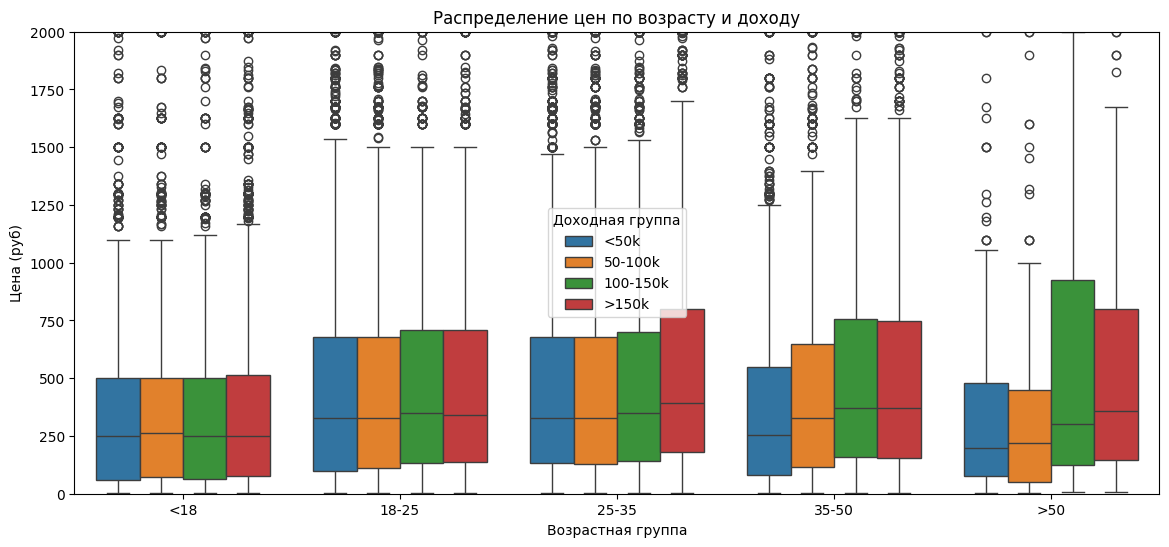

In [18]:
df['age_group'] = pd.cut(df['age'], 
                        bins=[0, 18, 25, 35, 50, np.inf],
                        labels=['<18', '18-25', '25-35', '35-50', '>50'])

df['income_group'] = pd.cut(df['monthly_income_amt'], 
                        bins=[0, 50000, 100000, 150000, np.inf],
                        labels=['<50k', '50-100k', '100-150k', '>150k'])

plt.figure(figsize=(14, 6))
snc.boxplot(data=df, x='age_group', y='good_price', hue='income_group')
plt.title('Распределение цен по возрасту и доходу')
plt.ylabel('Цена (руб)')
plt.xlabel('Возрастная группа')
plt.ylim((0, 2000))
plt.legend(title='Доходная группа')
plt.show()

Особое внимание обратим на то, что преимущественно во всех категориях с ростом дохода растет средний чек на игру. Дальше с помощью этого выделим и оценим, какие изменения применить к скидочной системе и ценообразованию для пользователя в зависимости от имеющейся о нем информации.

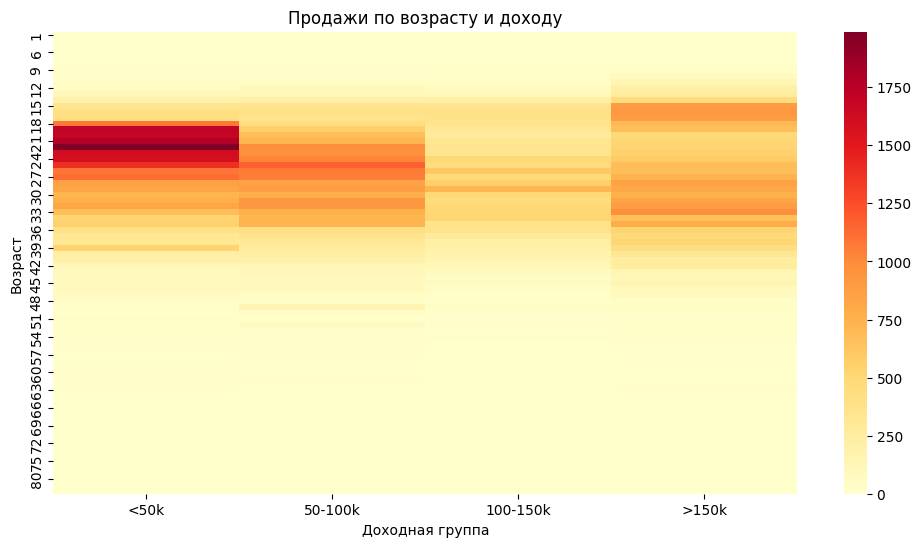

In [19]:
df['income_group'] = pd.cut(df['monthly_income_amt'], 
                        bins=[0, 50000, 100000, 150000, np.inf],
                        labels=['<50k', '50-100k', '100-150k', '>150k'])

discount_strategy = df.groupby(['age', 'income_group']).agg(
    avg_price=('good_price', 'mean'),
    total_sales=('good_cnt', 'sum')
).reset_index()
pivot_table = discount_strategy.pivot(index='age', 
                                    columns='income_group', 
                                    values='total_sales')

plt.figure(figsize=(12, 6))
snc.heatmap(pivot_table, cmap='YlOrRd')
plt.title('Продажи по возрасту и доходу')
plt.xlabel('Доходная группа')
plt.ylabel('Возраст')
plt.show()

Чтобы предлагать игры со скидками наиболее эффективно, нужно понять, что привлечет пользователей той или иной крупной категории. Для этого нужно выделить пользователей, которые являются целевыми в зависимости от дохода (ранее мы это выясняли, группируя по жанру и возрасту). Проще говоря, для людей с разным уровнем дохода подходят разные скидки, значит, взяв произвольного пользователя или потенциального пользователя в возрасте 22 года можно вероятностно оценить его уровень дохода, тогда для него подойдут скидки, подходящие под две первые доходные группы. А уже сами скидки и игры, на которые они нацелены, подбираются отдельно для каждой категории. Мы также узнали, что люди с большим доходом позволяют себе более дорогие игры, значит их привлечет даже небольшая скидка на дорогостоящую игру. А для людей со средним уровнем дохода больше подойдет скидка на медианную цену (в нашем случае на игру с ориентированной стоимостью в 500р).

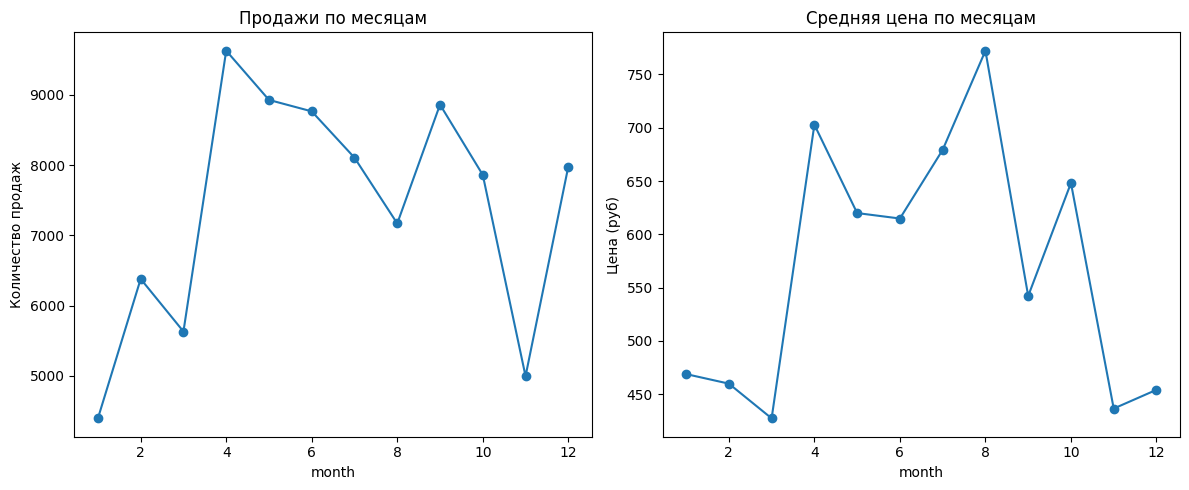

In [20]:
df['month'] = df['order_day'].dt.month
df['day_of_week'] = df['order_day'].dt.day_name()
df['is_weekend'] = df['order_day'].dt.dayofweek.isin([5,6])

monthly_sales = df.groupby('month').agg({
    'good_price': 'mean',
    'good_cnt': 'sum',
    'revenue': 'sum'
})

plt.figure(figsize=(12, 5))
plt.subplot(1,2,1)
monthly_sales['good_cnt'].plot(marker='o')
plt.title('Продажи по месяцам')
plt.ylabel('Количество продаж')

plt.subplot(1,2,2)
monthly_sales['good_price'].plot(marker='o')
plt.title('Средняя цена по месяцам')
plt.ylabel('Цена (руб)')
plt.tight_layout()
plt.show()

weekday_sales = df.groupby('day_of_week').agg({
    'good_cnt': 'mean',
    'good_price': 'mean'
}).reindex(['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday'])
plt.show()

Оценим графики с зависимостью цены и количества продаж от месяца. Выделяется апрель, который одновременно самый сезонный и дорогой месяц. В этом случае он отлично подходит для небольших скидок на игры с чеком выше среднего, так как в основном такие игры и покупаются пользователями. Также стоит обратить внимание на сентябрь, где большое количество совершенных покупок по маленькой цене. Не исключено, что небольшая скидка на покупаемые игры в это время еще сильнее увеличит количество покупок.

In [21]:
discount_stats = df.groupby('is_discounted').agg(
    avg_price=('good_price', 'mean'),
    total_sales=('good_cnt', 'sum'),
    total_revenue=('revenue', 'sum')
)
print(discount_stats)

                avg_price  total_sales  total_revenue
is_discounted                                        
False          592.396613      81018.0    47994788.81
True           500.078244       7681.0     3841100.99


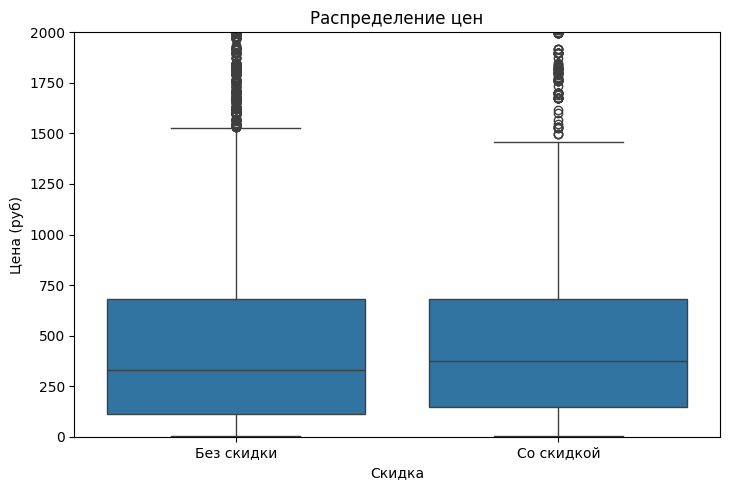

In [22]:
plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
snc.boxplot(data=df, x='is_discounted', y='good_price')
plt.title('Распределение цен')
plt.xlabel('Скидка')
plt.ylabel('Цена (руб)')
plt.ylim((0, 2000))
plt.xticks([0, 1], ['Без скидки', 'Со скидкой'])

plt.tight_layout()
plt.show()

Обратися к имеющимся данным о скидках, их не так много для точного прогнозирования, тем более не всю информацию о скидках мы знаем (допустим, не знаем категорию игры, на которую действует скидка, или время, в течении которого она действует), но данных достаточно, чтобы составить гипотезы о текущей стратегии формирования скидок. Поскольку средние значения цены товаров со скидкой практически не отличается от товаров без скидки, предположительно скидка действует на игры с как минимум медианной стоимостью, что в действительности обоснованно. В таком случае мы уже выяснили, какая аудитория у игр данного ценового сегмента, далее мы рассмотрим такой фактор, как популярность игры, но уже сейчас можем описать как минимум одну группу, для которой подходит большинство действующих скидок. Как один из примеров, для скидок на RPG подходят пользователи в возрасте 21-26 лет из 2-3 доходных групп, в идеале из Москва, Самары или Новосибирска. **Делаем такой вывод, исходя из того, что:**
1. Данный жанр показывает положительную корреляцию, а его средняя цена сопоставима со средней ценой скидок (то есть и дальнейшие рассуждения для продаж игр со скидкой правдивы).
2. Средняя стоимость покупок со скидкой больше всего подходит под 2-3 доходные группы, а именно среди них больше всего покупателей в возрасте 21-26 лет, значит это самый широкий круг из целевой аудитории.
3. Также мы предполагаем, что данные рекомендации уже для действующих пользователей, а больше всего вероятность покупок у пользователей, которых мы выделили как заядлых геймеров.

Вот пример на конкретных данных. Это не значит, что другим пользователям не стоит рекомендовать данную игру, но в конкретный момент выше всего доля покупок относительно показов окажется у выделенной группы. Далее перед стартом любой скидочной акции можно выделить свою наиболее активную группу, а данные, которые появятся после новых запусков,можно использовать для изменения характеристик, потому что через время на конкретные жанры и стоимость может быть востребованность у совершенно разных кластеров пользователей.

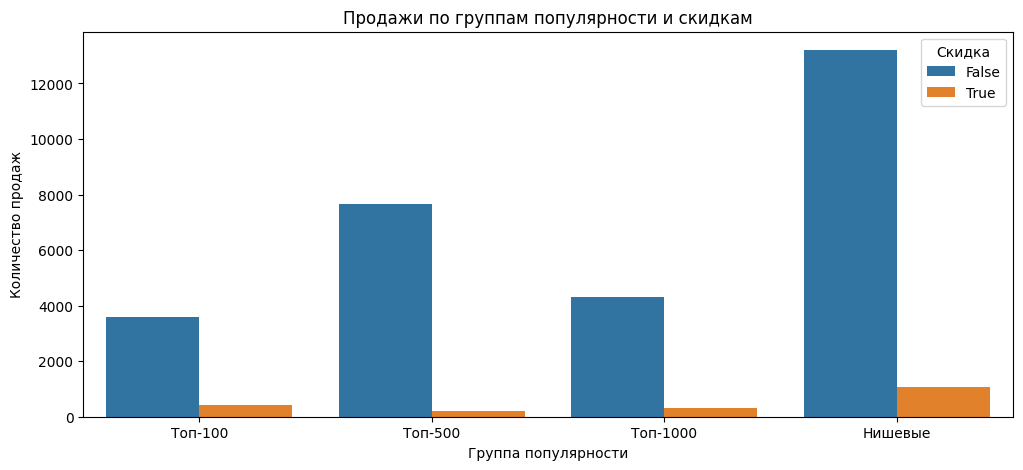

In [23]:
df['popularity_group'] = pd.cut(df['steam_popularity_score'], 
                            bins=[0, 100, 500, 1000, np.inf],
                            labels=['Топ-100', 'Топ-500', 'Топ-1000', 'Нишевые'])

popularity_discount = df.groupby(['popularity_group', 'is_discounted']).agg({
    'good_price': 'mean',
    'good_cnt': 'sum',
    'revenue': 'sum'
}).reset_index()

plt.figure(figsize=(12, 5))
snc.barplot(data=popularity_discount, x='popularity_group', y='good_cnt', hue='is_discounted')
plt.title('Продажи по группам популярности и скидкам')
plt.ylabel('Количество продаж')
plt.xlabel('Группа популярности')
plt.legend(title='Скидка')
plt.show()

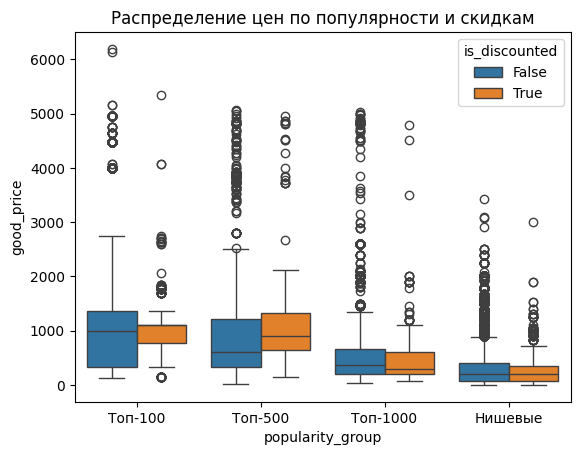

In [24]:
df['popularity_group'] = pd.cut(df['steam_popularity_score'], 
                            bins=[0, 100, 500, 1000, np.inf],
                            labels=['Топ-100', 'Топ-500', 'Топ-1000', 'Нишевые'])

snc.boxplot(data=df, x='popularity_group', y='good_price', hue='is_discounted')
plt.title('Распределение цен по популярности и скидкам')
plt.show()

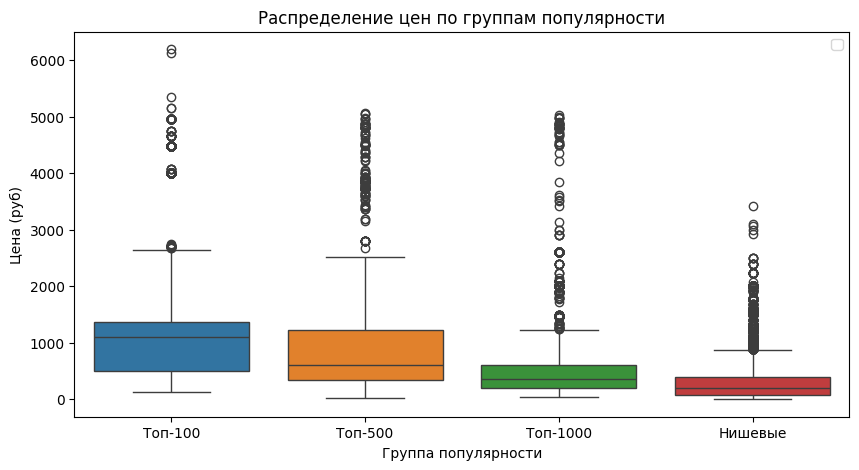

In [25]:
df['popularity_group'] = pd.cut(df['steam_popularity_score'], 
                            bins=[0, 100, 500, 1000, np.inf],
                            labels=['Топ-100', 'Топ-500', 'Топ-1000', 'Нишевые'])

plt.figure(figsize=(10, 5))
snc.boxplot(data=df, x='popularity_group', y='good_price', hue='popularity_group')
plt.title('Распределение цен по группам популярности')
plt.ylabel('Цена (руб)')
plt.xlabel('Группа популярности')
plt.legend('')
plt.show()

Нужно рассмотреть и популярность игры, потому что для предложенного разбиения на рекомендательные кластеры. Условно, при глобальной акции на топ 100 игр стима можно оценить, кому больше всего рекомендовать покупку, так как мы уже будем знать топ жанров и среднюю (медианную) цену игр, а это явно сужает круг рассматриваемых потенциальных покупателей.

In [26]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

user_features = df.groupby('client_id').agg({
    'monthly_income_amt': 'mean',
    'age': 'mean',
    'good_price': ['mean', 'max'],
    'order_day': 'count'
}).reset_index()
user_features.columns = ['client_id', 'income', 'age', 'avg_spent', 'max_spent', 'purchase_freq']

scaler = StandardScaler()
X = scaler.fit_transform(user_features[['income', 'age', 'avg_spent', 'purchase_freq']])
kmeans = KMeans(n_clusters=4).fit(X)
user_features['segment'] = kmeans.labels_

segment_stats = user_features.groupby('segment').agg({
    'income': 'mean',
    'age': 'mean',
    'avg_spent': 'mean',
    'purchase_freq': 'mean'
}).round(1)
print(segment_stats)

           income   age  avg_spent  purchase_freq
segment                                          
0         95284.4  28.6      349.9           28.9
1         64463.9  20.3      419.2            1.8
2        101735.5  27.7     3426.6            1.5
3        124834.7  34.5      536.6            2.1


В ходе анализа мы вывели ключевые закономерности, которые позволяют понять какой объем продаж  будет в зависимости от цены, жанра и популярности игры. Для этого, мы выбрали стратегию разбиения на сегменты игр и пользователей, которые можно с собой сопоставить, например: Пользователь в возрасте 23-26 лет имеющий доход 50-100к, вероятно, не откажется от приобретения одной из популярных игр жанра RPG, если ее цена находится близка к средней стоимости игр в этом жанре, а в данный момент на нее действует скидка(около 10%). Т.е. для увеличения количества продаж и проведения с этой целью различных акций, важно посмотреть на аудиторию, которая рассчитана на покупку этой игры. Ранее были выведены зависимости между доходом, местом жительства, возраст пользователей(их мы объединили в отдельный пользовательский сегмент) и сегментом игр, который описывается такими характеристиками как жанр, популярность и цена.